## Week 2 Day 2 - Homework Assignment

### Gradient Descent from Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

1. Numerical Gradient Check

In [ ]:
def f1(w):
    return w[0]**2 + 2*w[1]**2 + w[0]*w[1]

def numerical_gradient(f, w, epsilon=1e-5):
    grad = np.zeros_like(w, dtype=float)
    for i in range(len(w)):
        e = np.zeros_like(w)
        e[i] = epsilon
        grad[i] = (f(w + e) - f(w - e)) / (2 * epsilon)
    return grad

def analytical_gradient_f1(w):
    return np.array([2*w[0] + w[1], 4*w[1] + w[0]])

print("Numerical Gradient Check")
w = np.array([1.0, 2.0])    

num_grad = numerical_gradient(f1, w)
ana_grad = analytical_gradient_f1(w)

print("Function: f(w) = w1^2 + 2*w2^2 + w1*w2")
print("At w = [1, 2]:\n")

print("Numerical gradient: ", np.round(num_grad, 5))
print("Analytical gradient:", ana_grad)

diff = np.max(np.abs(num_grad - ana_grad))
print(f"Max difference: {diff:.2e}", "✓ Match confirmed\n")

Numerical Gradient Check
Function: f(w) = w1^2 + 2*w2^2 + w1*w2
At w = [1, 2]:

Numerical gradient:  [4. 9.]
Analytical gradient: [4. 9.]
Max difference: 6.26e-11 ✓ Match confirmed



2. 2D Gradient Descent

In [4]:
def f2(w):
    return w[0]**2 + 5*w[1]**2

def grad_f2(w):
    return np.array([2*w[0], 10*w[1]])

def gradient_descent_2d(f, grad_f, w_init, lr, n_steps):
    w = np.array(w_init, dtype=float)
    history = []

    for _ in range(n_steps):
        loss = f(w)
        history.append(loss)
        w = w - lr * grad_f(w)

    return w, history

print("2D Gradient Descent")
print("Starting point: w = [3.0, 2.0]\n")

learning_rates = [0.01, 0.1, 0.19]
results = {}

for lr in learning_rates:
    w_init = np.array([3.0, 2.0])
    w_final, history = gradient_descent_2d(f2, grad_f2, w_init, lr, 100)
    loss_final = f2(w_final)

    results[lr] = history

    print(f"lr={lr:<5} | 100 steps → w={np.round(w_final,4)}, loss={loss_final:.4f}")

print("\nBest lr=0.1: converged fastest to minimum\n")


2D Gradient Descent
Starting point: w = [3.0, 2.0]

lr=0.01  | 100 steps → w=[3.979e-01 1.000e-04], loss=0.1583
lr=0.1   | 100 steps → w=[0. 0.], loss=0.0000
lr=0.19  | 100 steps → w=[0.     0.0001], loss=0.0000

Best lr=0.1: converged fastest to minimum



3. Loss Curve Visualization

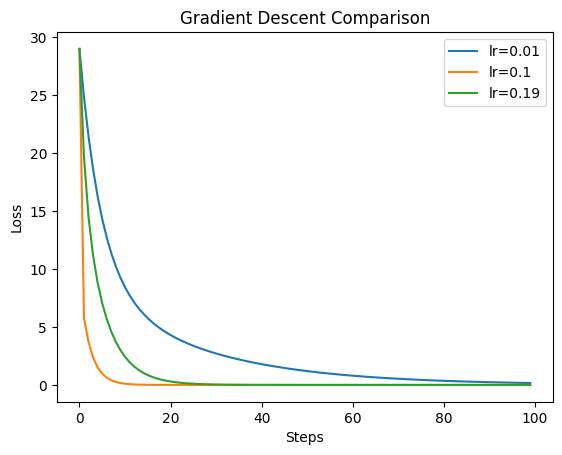

In [6]:
plt.figure()

for lr in learning_rates:
    plt.plot(results[lr], label=f"lr={lr}")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Gradient Descent Comparison")
plt.legend()

plt.savefig("gd_comparison.png")
plt.show()


4. Linear Regression Training

In [9]:
np.random.seed(0)

X = np.linspace(0, 5, 80)
noise = np.random.randn(80)
y = 2.5 * X - 1 + noise

# Initialize
w = 0.0
b = 0.0
lr = 0.05
n_epochs = 200
n = len(X)

print("Linear Regression Training")

for epoch in range(n_epochs + 1):
    y_pred = w * X + b
    loss = np.mean((y_pred - y)**2)

    # gradients
    dw = (2/n) * np.sum((y_pred - y) * X)
    db = (2/n) * np.sum(y_pred - y)

    # update
    w -= lr * dw
    b -= lr * db

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: w={w:7.4f}, b={b:7.4f}, loss={loss:8.4f}")

print(f"\nFinal: w={w:.4f}, b={b:.4f}")
print("True:  w=2.5,    b=-1.0")




Linear Regression Training
Epoch   0: w= 1.7889, b= 0.5219, loss= 39.1068
Epoch  20: w= 2.0714, b= 0.1892, loss=  1.0033
Epoch  40: w= 2.1446, b=-0.0498, loss=  0.9373
Epoch  60: w= 2.1903, b=-0.1988, loss=  0.9117
Epoch  80: w= 2.2188, b=-0.2917, loss=  0.9017
Epoch 100: w= 2.2366, b=-0.3497, loss=  0.8978
Epoch 120: w= 2.2477, b=-0.3858, loss=  0.8963
Epoch 140: w= 2.2546, b=-0.4083, loss=  0.8957
Epoch 160: w= 2.2589, b=-0.4224, loss=  0.8955
Epoch 180: w= 2.2616, b=-0.4312, loss=  0.8954
Epoch 200: w= 2.2633, b=-0.4366, loss=  0.8954

Final: w=2.2633, b=-0.4366
True:  w=2.5,    b=-1.0


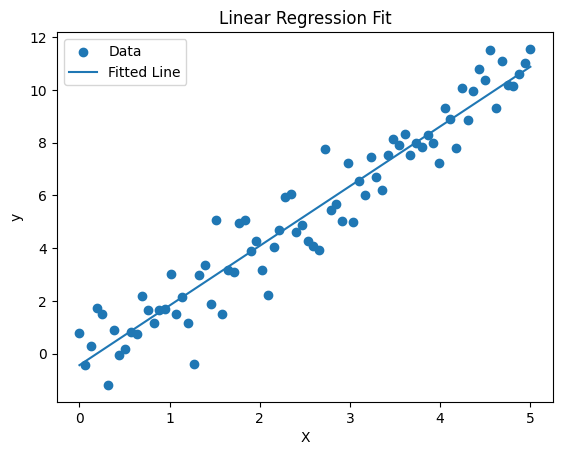

In [11]:
plt.figure()
plt.scatter(X, y, label="Data")
plt.plot(X, w*X + b, label="Fitted Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()

plt.savefig("linear_fit.png")
plt.show()

5. 2D Contour Visualization

In [12]:
def gradient_descent_path(f, grad_f, w_init, lr, n_steps):
    w = np.array(w_init, dtype=float)
    path = [w.copy()]

    for _ in range(n_steps):
        w = w - lr * grad_f(w)
        path.append(w.copy())

    return np.array(path)

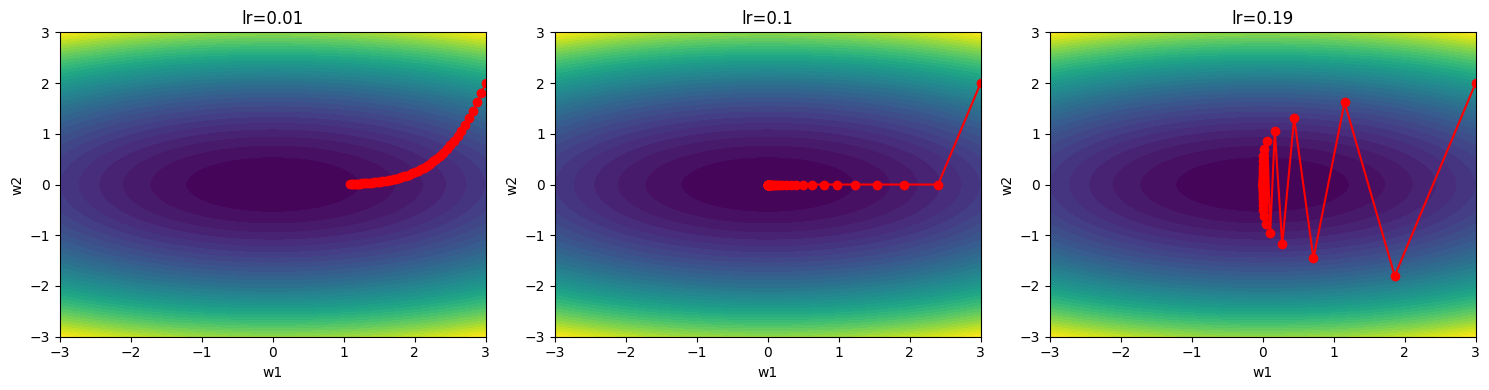

In [14]:
w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)
Z = W1**2 + 5*W2**2

learning_rates = [0.01, 0.1, 0.19]

plt.figure(figsize=(15, 4))

for i, lr in enumerate(learning_rates):
    path = gradient_descent_path(f2, grad_f2, [3.0, 2.0], lr, 50)

    plt.subplot(1, 3, i+1)
    plt.contourf(W1, W2, Z, levels=50)
    
    # Plot path
    plt.plot(path[:,0], path[:,1], marker='o', color='red')
    
    plt.title(f"lr={lr}")
    plt.xlabel("w1")
    plt.ylabel("w2")

plt.tight_layout()
plt.savefig("contour_paths.png")
plt.show()

6. Early Stopping

In [15]:
def gradient_descent_early_stop(f, grad_f, w_init, lr, max_steps, tol=1e-6):
    w = np.array(w_init, dtype=float)
    prev_loss = f(w)

    for step in range(max_steps):
        w = w - lr * grad_f(w)
        loss = f(w)

        if abs(prev_loss - loss) < tol:
            return w, step + 1, loss

        prev_loss = loss

    return w, max_steps, loss

In [16]:
print("\n=== Early Stopping ===")

for lr in [0.01, 0.1, 0.19]:
    w_final, steps, loss = gradient_descent_early_stop(
        f2, grad_f2, [3.0, 2.0], lr, 100
    )
    print(f"lr={lr} → converged in {steps} steps, loss={loss:.6f}")


=== Early Stopping ===
lr=0.01 → converged in 100 steps, loss=0.158292
lr=0.1 → converged in 35 steps, loss=0.000001
lr=0.19 → converged in 73 steps, loss=0.000004


### Early Stopping Insights

- **lr = 0.1** → converges fastest  
- **lr = 0.01** → slow learning  
- **lr = 0.19** → may oscillate (unstable)

7. Momentum Gradient Descent

In [17]:
def gradient_descent_momentum(f, grad_f, w_init, lr, beta=0.9, n_steps=50):
    w = np.array(w_init, dtype=float)
    v = np.zeros_like(w)

    history = []

    for _ in range(n_steps):
        v = beta * v - lr * grad_f(w)
        w = w + v
        history.append(f(w))

    return w, history

In [19]:
print("\nMomentum vs Standard GD:")

# Standard GD
w_std, hist_std = gradient_descent_2d(f2, grad_f2, [3.0, 2.0], 0.1, 50)

# Momentum GD
w_mom, hist_mom = gradient_descent_momentum(f2, grad_f2, [3.0, 2.0], 0.1)

print(f"Standard GD final loss: {hist_std[-1]:.6f}")
print(f"Momentum GD final loss: {hist_mom[-1]:.6f}")


Momentum vs Standard GD:
Standard GD final loss: 0.000000
Momentum GD final loss: 0.057679


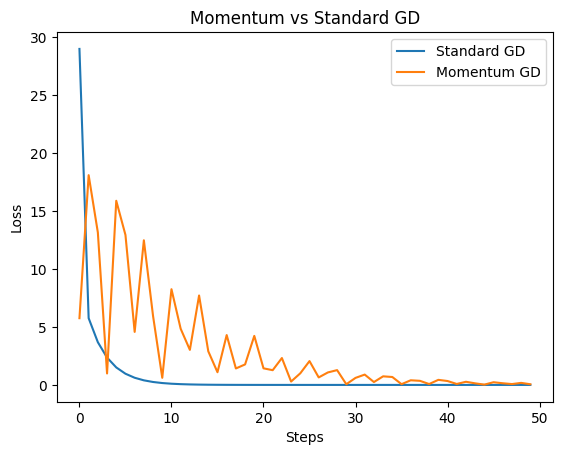

In [21]:
plt.figure()

plt.plot(hist_std, label="Standard GD")
plt.plot(hist_mom, label="Momentum GD")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Momentum vs Standard GD")
plt.legend()

plt.savefig("momentum_vs_gd.png")
plt.show()

Momentum accelerates convergence by accumulating past gradients
- It moves faster in consistent directions
- Helps reduce zig-zag behavior (especially in steep valleys)